In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Resolve the repository root whether this notebook is run from the repo root or notebooks/.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
df = pd.read_csv(PROCESSED_DIR / "cleaned_transfers.csv")

print("Cleaned data shape:", df.shape)
df.head()


Cleaned data shape: (70005, 33)


,league,season,window,team_id,team_name,team_country,dir,player_id,player_name,player_age,player_nation,player_nation2,player_pos,counter_team_id,counter_team_name,counter_team_country,transfer_fee_amnt,market_val_amnt,is_free,is_loan,is_loan_end,is_retired,transfer_id,league_name,transfer_type,source_club,target_club,source_country,target_country,transfer_fee_clean,market_value_clean,fee_observed,market_value_observed
0,GB1,2009,s,985,Manchester United,England,in,33544,Antonio Valencia,23.0,Ecuador,NaN,RB,1071,Wigan Athletic,England,18800000.0,NaN,False,False,False,False,310832,Premier League,Paid/undisclosed,Wigan Athletic,Manchester United,England,England,18800000.0,NaN,True,False
1,GB1,2009,s,985,Manchester United,England,in,62049,Mame Diouf,21.0,Senegal,NaN,CF,687,Molde FK,Norway,4500000.0,1600000.0,False,False,False,False,319841,Premier League,Paid/undisclosed,Molde FK,Manchester United,Norway,England,4500000.0,1600000.0,True,True
2,GB1,2009,s,985,Manchester United,England,in,43261,Gabriel Obertan,20.0,France,Guadeloupe,AM,40,FC Girondins Bordeaux,France,4000000.0,400000.0,False,False,False,False,315185,Premier League,Paid/undisclosed,FC Girondins Bordeaux,Manchester United,France,England,4000000.0,400000.0,True,True
3,GB1,2009,s,985,Manchester United,England,in,1397,Michael Owen,29.0,England,NaN,CF,762,Newcastle United,England,0.0,NaN,True,False,False,False,306421,Premier League,Free transfer,Newcastle United,Manchester United,England,England,0.0,NaN,True,False
4,GB1,2009,s,985,Manchester United,England,in,73538,Scott Moffatt,18.0,England,NaN,CB,5242,Manchester United U18,England,NaN,NaN,False,False,False,False,339015,Premier League,Paid/undisclosed,Manchester United U18,Manchester United,England,England,NaN,NaN,False,False


In [3]:
invalid_clubs = [
    "Without Club",
    "Retired",
    "Career break",
    "Unknown",
    "No Club"
]

df = df[
    ~df["source_club"].isin(invalid_clubs) &
    ~df["target_club"].isin(invalid_clubs)
].copy()

In [4]:
df[
    [
        "season",
        "league_name",
        "source_club",
        "target_club",
        "source_country",
        "target_country",
        "player_name",
        "player_pos",
        "transfer_fee_clean",
        "transfer_type"
    ]
].head()

,season,league_name,source_club,target_club,source_country,target_country,player_name,player_pos,transfer_fee_clean,transfer_type
0,2009,Premier League,Wigan Athletic,Manchester United,England,England,Antonio Valencia,RB,18800000.0,Paid/undisclosed
1,2009,Premier League,Molde FK,Manchester United,Norway,England,Mame Diouf,CF,4500000.0,Paid/undisclosed
2,2009,Premier League,FC Girondins Bordeaux,Manchester United,France,England,Gabriel Obertan,AM,4000000.0,Paid/undisclosed
3,2009,Premier League,Newcastle United,Manchester United,England,England,Michael Owen,CF,0.0,Free transfer
4,2009,Premier League,Manchester United U18,Manchester United,England,England,Scott Moffatt,CB,NaN,Paid/undisclosed


In [5]:
df[["source_club", "target_club"]].isna().sum()

source_club    0
target_club    0
dtype: int64

In [6]:
df[
    [
        "team_name",
        "dir",
        "counter_team_name",
        "source_club",
        "target_club",
        "player_name",
        "transfer_fee_clean"
    ]
].sample(10, random_state=42)

,team_name,dir,counter_team_name,source_club,target_club,player_name,transfer_fee_clean
63480,FC Groningen,in,VVV-Venlo,VVV-Venlo,FC Groningen,Gonzalo García,NaN
47340,SCO Angers,left,Clermont Foot 63,SCO Angers,Clermont Foot 63,Ludovic Ajorque,NaN
14150,Atlético de Madrid,in,Villarreal CF,Villarreal CF,Atlético de Madrid,Sergio Asenjo,NaN
28227,AC Milan,left,Hellas Verona,AC Milan,Hellas Verona,Michelangelo Albertazzi,0.0
45859,AS Monaco,in,CA Bastia,CA Bastia,AS Monaco,Aadil Assana,NaN
18745,Atlético de Madrid,in,AS Roma,AS Roma,Atlético de Madrid,Nikola Kalinic,NaN
47962,EA Guingamp,in,Clermont Foot 63,Clermont Foot 63,EA Guingamp,Marc-Aurèle Caillard,NaN
58705,Portimonense SC,in,FC Porto B,FC Porto B,Portimonense SC,Chidera Ezeh,NaN
27740,Juventus FC,left,AS Livorno,Juventus FC,AS Livorno,Cristian Bunino,NaN
26077,Udinese Calcio,left,Brescia Calcio,Udinese Calcio,Brescia Calcio,Daniele Mori,NaN


In [7]:
club_edges = (
    df.groupby(["source_club", "target_club"])
      .agg(
          transfer_count=("transfer_id", "count"),

          # min_count=1 means:
          # if every fee on an edge is missing, the total remains NaN
          # rather than being reported as 0.
          total_transfer_fee=(
              "transfer_fee_clean",
              lambda values: values.sum(min_count=1)
          ),

          # mean and max automatically ignore NaN values.
          average_transfer_fee=("transfer_fee_clean", "mean"),
          maximum_transfer_fee=("transfer_fee_clean", "max"),

          # Number of transfers on this edge with an observed fee.
          observed_fee_count=("transfer_fee_clean", "count"),

          first_season=("season", "min"),
          last_season=("season", "max"),

          source_country=("source_country", "first"),
          target_country=("target_country", "first")
      )
      .reset_index()
)

# Proportion of transfers on each edge for which a fee was observed.
club_edges["fee_coverage"] = (
    club_edges["observed_fee_count"]
    / club_edges["transfer_count"]
)

In [8]:
club_edges.shape

(31272, 12)

In [9]:
club_edges.sort_values("transfer_count", ascending=False).head(20)

,source_club,target_club,transfer_count,total_transfer_fee,average_transfer_fee,maximum_transfer_fee,observed_fee_count,first_season,last_season,source_country,target_country,fee_coverage
29028,Udinese Calcio,Watford FC,59,63000000.0,4.500000e+06,10600000.0,14,2012,2020,Italy,England,0.237288
28907,Udinese Calcio,Granada CF,57,10000000.0,1.666667e+06,5000000.0,6,2009,2019,Italy,Spain,0.105263
14692,Granada CF,Udinese Calcio,52,23191000.0,1.288389e+06,4000000.0,18,2011,2018,Spain,Italy,0.346154
13905,Genoa CFC,AC Milan,49,261600000.0,8.175000e+06,35000000.0,32,2009,2018,Italy,Italy,0.653061
12444,FC Stade Rennes B,Stade Rennais FC,47,NaN,NaN,NaN,0,2009,2021,France,France,0.000000
29936,Vitesse Arnhem,Chelsea FC,46,18800000.0,9.400000e+06,9400000.0,2,2011,2020,Netherlands,England,0.043478
4443,Bilbao Athletic,Athletic Bilbao,45,NaN,NaN,NaN,0,2009,2021,Spain,Spain,0.000000
11080,FC Girondins Bordeaux B,FC Girondins Bordeaux,45,NaN,NaN,NaN,0,2009,2021,France,France,0.000000
19470,Olympique Lyon B,Olympique Lyon,44,NaN,NaN,NaN,0,2009,2021,France,France,0.000000
7557,Chelsea FC,Vitesse Arnhem,44,NaN,NaN,NaN,0,2010,2019,England,Netherlands,0.000000


In [10]:
club_edges.sort_values("transfer_count", ascending=False).head(20)[
    [
        "source_club",
        "target_club",
        "transfer_count",
        "total_transfer_fee",
        "first_season",
        "last_season"
    ]
]

,source_club,target_club,transfer_count,total_transfer_fee,first_season,last_season
29028,Udinese Calcio,Watford FC,59,63000000.0,2012,2020
28907,Udinese Calcio,Granada CF,57,10000000.0,2009,2019
14692,Granada CF,Udinese Calcio,52,23191000.0,2011,2018
13905,Genoa CFC,AC Milan,49,261600000.0,2009,2018
12444,FC Stade Rennes B,Stade Rennais FC,47,NaN,2009,2021
29936,Vitesse Arnhem,Chelsea FC,46,18800000.0,2011,2020
4443,Bilbao Athletic,Athletic Bilbao,45,NaN,2009,2021
11080,FC Girondins Bordeaux B,FC Girondins Bordeaux,45,NaN,2009,2021
19470,Olympique Lyon B,Olympique Lyon,44,NaN,2009,2021
7557,Chelsea FC,Vitesse Arnhem,44,NaN,2010,2019


In [11]:
club_edges.sort_values(
    "total_transfer_fee",
    ascending=False
).head(20)[
    [
        "source_club",
        "target_club",
        "transfer_count",
        "total_transfer_fee",
        "average_transfer_fee",
        "maximum_transfer_fee",
        "observed_fee_count",
        "fee_coverage"
    ]
]

,source_club,target_club,transfer_count,total_transfer_fee,average_transfer_fee,maximum_transfer_fee,observed_fee_count,fee_coverage
27900,UC Sampdoria,AS Roma,15,1.592000e+09,1.768889e+08,500000000.0,9,0.600000
20338,Parma FC,Novara Calcio 1908,4,1.000600e+09,2.501500e+08,500000000.0,4,1.000000
6927,Calcio Catania,Ascoli Calcio 1898,7,5.500000e+08,5.500000e+08,550000000.0,1,0.142857
20485,Piacenza FC,Genoa CFC,1,5.500000e+08,5.500000e+08,550000000.0,1,1.000000
28055,UC Sampdoria,SSC Napoli,10,5.420000e+08,7.742857e+07,500000000.0,7,0.700000
7647,Chievo Verona,AC Cesena,11,5.036800e+08,1.259200e+08,500000000.0,4,0.363636
3261,Ascoli Calcio 1898,Calcio Catania,3,5.032000e+08,1.677333e+08,500000000.0,3,1.000000
16269,Juventus FC,Vicenza Calcio,9,5.031000e+08,1.006200e+08,500000000.0,5,0.555556
28577,US Palermo,Vicenza Calcio,7,5.002000e+08,2.501000e+08,500000000.0,2,0.285714
14179,Genoa CFC,Vicenza Calcio,10,5.002000e+08,2.501000e+08,500000000.0,2,0.200000


In [12]:
source_nodes = df[["source_club", "source_country"]].rename(
    columns={
        "source_club": "club",
        "source_country": "country"
    }
)

target_nodes = df[["target_club", "target_country"]].rename(
    columns={
        "target_club": "club",
        "target_country": "country"
    }
)

club_nodes = pd.concat([source_nodes, target_nodes], ignore_index=True)
club_nodes = club_nodes.drop_duplicates(subset=["club"]).reset_index(drop=True)

club_nodes.head()

,club,country
0,Wigan Athletic,England
1,Molde FK,Norway
2,FC Girondins Bordeaux,France
3,Newcastle United,England
4,Manchester United U18,England


In [13]:
club_nodes.shape

(3606, 2)

In [14]:
transfers_out = (
    df.groupby("source_club")
    .agg(
        transfers_out=("transfer_id", "count"),
        total_fee_out=("transfer_fee_clean", "sum")
    )
    .reset_index()
    .rename(columns={"source_club": "club"})
)

transfers_in = (
    df.groupby("target_club")
    .agg(
        transfers_in=("transfer_id", "count"),
        total_fee_in=("transfer_fee_clean", "sum")
    )
    .reset_index()
    .rename(columns={"target_club": "club"})
)

club_nodes = club_nodes.merge(transfers_out, on="club", how="left")
club_nodes = club_nodes.merge(transfers_in, on="club", how="left")

club_nodes[["transfers_out", "total_fee_out", "transfers_in", "total_fee_in"]] = club_nodes[
    ["transfers_out", "total_fee_out", "transfers_in", "total_fee_in"]
].fillna(0)

club_nodes["total_transfers"] = club_nodes["transfers_out"] + club_nodes["transfers_in"]
club_nodes["total_fee_involved"] = club_nodes["total_fee_out"] + club_nodes["total_fee_in"]

club_nodes.head()

,club,country,transfers_out,total_fee_out,transfers_in,total_fee_in,total_transfers,total_fee_involved
0,Wigan Athletic,England,143.0,153050000.0,155.0,81775000.0,298.0,2.348250e+08
1,Molde FK,Norway,16.0,17260000.0,8.0,2000000.0,24.0,1.926000e+07
2,FC Girondins Bordeaux,France,256.0,471620000.0,272.0,251180000.0,528.0,7.228000e+08
3,Newcastle United,England,274.0,567420000.0,293.0,849790000.0,567.0,1.417210e+09
4,Manchester United U18,England,15.0,0.0,0.0,0.0,15.0,0.000000e+00


In [15]:
club_nodes.sort_values("total_transfers", ascending=False).head(20)[
    [
        "club",
        "country",
        "transfers_in",
        "transfers_out",
        "total_transfers",
        "total_fee_involved"
    ]
]

,club,country,transfers_in,transfers_out,total_transfers,total_fee_involved
130,Genoa CFC,Italy,637.0,998.0,1635.0,3.960927e+09
129,SL Benfica,Portugal,637.0,648.0,1285.0,2.902065e+09
262,FC Porto,Portugal,586.0,615.0,1201.0,2.297978e+09
263,Juventus FC,Italy,413.0,779.0,1192.0,5.522158e+09
253,Parma FC,Italy,421.0,771.0,1192.0,3.499643e+09
437,Udinese Calcio,Italy,387.0,791.0,1178.0,1.930797e+09
37,Chelsea FC,England,569.0,574.0,1143.0,5.333672e+09
14,AS Roma,Italy,413.0,727.0,1140.0,5.102377e+09
174,SC Braga,Portugal,567.0,549.0,1116.0,5.937920e+08
552,Atalanta BC,Italy,330.0,777.0,1107.0,2.300069e+09


In [16]:
G = nx.DiGraph()

# Add nodes
for _, row in club_nodes.iterrows():
    G.add_node(
        row["club"],
        country=row["country"],
        transfers_in=row["transfers_in"],
        transfers_out=row["transfers_out"],
        total_transfers=row["total_transfers"],
        total_fee_involved=row["total_fee_involved"]
    )

# Add edges
for _, row in club_edges.iterrows():
    G.add_edge(
        row["source_club"],
        row["target_club"],

        transfer_count=row["transfer_count"],
        total_transfer_fee=row["total_transfer_fee"],
        average_transfer_fee=row["average_transfer_fee"],
        maximum_transfer_fee=row["maximum_transfer_fee"],
        observed_fee_count=row["observed_fee_count"],
        fee_coverage=row["fee_coverage"],

        first_season=row["first_season"],
        last_season=row["last_season"],

        source_country=row["source_country"],
        target_country=row["target_country"]
    )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 3606
Number of edges: 31272


In [17]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Network density:", density)

Number of nodes: 3606
Number of edges: 31272
Network density: 0.002405606928812589


In [18]:
degree_dict = dict(G.degree())
in_degree_dict = dict(G.in_degree())
out_degree_dict = dict(G.out_degree())

club_nodes["degree"] = club_nodes["club"].map(degree_dict)
club_nodes["in_degree"] = club_nodes["club"].map(in_degree_dict)
club_nodes["out_degree"] = club_nodes["club"].map(out_degree_dict)

club_nodes.head()

,club,country,transfers_out,total_fee_out,transfers_in,total_fee_in,total_transfers,total_fee_involved,degree,in_degree,out_degree
0,Wigan Athletic,England,143.0,153050000.0,155.0,81775000.0,298.0,2.348250e+08,144,75,69
1,Molde FK,Norway,16.0,17260000.0,8.0,2000000.0,24.0,1.926000e+07,17,6,11
2,FC Girondins Bordeaux,France,256.0,471620000.0,272.0,251180000.0,528.0,7.228000e+08,218,99,119
3,Newcastle United,England,274.0,567420000.0,293.0,849790000.0,567.0,1.417210e+09,252,128,124
4,Manchester United U18,England,15.0,0.0,0.0,0.0,15.0,0.000000e+00,3,0,3


In [19]:
weighted_in_degree = dict(G.in_degree(weight="transfer_count"))
weighted_out_degree = dict(G.out_degree(weight="transfer_count"))
weighted_degree = {
    club: weighted_in_degree.get(club, 0) + weighted_out_degree.get(club, 0)
    for club in G.nodes()
}

club_nodes["weighted_in_degree"] = club_nodes["club"].map(weighted_in_degree)
club_nodes["weighted_out_degree"] = club_nodes["club"].map(weighted_out_degree)
club_nodes["weighted_degree"] = club_nodes["club"].map(weighted_degree)

club_nodes.head()

,club,country,transfers_out,total_fee_out,transfers_in,total_fee_in,total_transfers,total_fee_involved,degree,in_degree,out_degree,weighted_in_degree,weighted_out_degree,weighted_degree
0,Wigan Athletic,England,143.0,153050000.0,155.0,81775000.0,298.0,2.348250e+08,144,75,69,155,143,298
1,Molde FK,Norway,16.0,17260000.0,8.0,2000000.0,24.0,1.926000e+07,17,6,11,8,16,24
2,FC Girondins Bordeaux,France,256.0,471620000.0,272.0,251180000.0,528.0,7.228000e+08,218,99,119,272,256,528
3,Newcastle United,England,274.0,567420000.0,293.0,849790000.0,567.0,1.417210e+09,252,128,124,293,274,567
4,Manchester United U18,England,15.0,0.0,0.0,0.0,15.0,0.000000e+00,3,0,3,0,15,15


In [20]:
import scipy
import scipy.sparse
import networkx as nx

print("SciPy:", scipy.__version__)
print("NetworkX:", nx.__version__)
print("sparse object:", scipy.sparse)
print("Has coo_array:", hasattr(scipy.sparse, "coo_array"))

SciPy: 1.15.2
NetworkX: 3.4.2
sparse object: <module 'scipy.sparse' from 'C:\\Users\\LENOVO\\anaconda3\\envs\\football_net\\lib\\site-packages\\scipy\\sparse\\__init__.py'>
Has coo_array: True


In [21]:
import scipy
import scipy.sparse as scipy_sparse
import networkx as nx

# Compatibility fix for SciPy/NetworkX
scipy.sparse = scipy_sparse

print("SciPy version:", scipy.__version__)
print("NetworkX version:", nx.__version__)
print("Sparse available:", hasattr(scipy, "sparse"))

pagerank_dict = nx.pagerank(
    G,
    alpha=0.85,
    weight="transfer_count",
    max_iter=1000,
    tol=1e-8
)

club_nodes["pagerank"] = (
    club_nodes["club"].map(pagerank_dict)
)

pagerank_top20 = (
    club_nodes.sort_values(
        "pagerank",
        ascending=False
    )
    .head(20)[
        [
            "club",
            "country",
            "degree",
            "in_degree",
            "out_degree",
            "weighted_degree",
            "pagerank"
        ]
    ]
)

pagerank_top20

SciPy version: 1.15.2
NetworkX version: 3.4.2
Sparse available: True


,club,country,degree,in_degree,out_degree,weighted_degree,pagerank
253,Parma FC,Italy,376,161,215,1192,0.008990
174,SC Braga,Portugal,358,175,183,1116,0.008810
129,SL Benfica,Portugal,436,219,217,1285,0.008657
262,FC Porto,Portugal,347,172,175,1201,0.007987
185,Sporting CP,Portugal,424,208,216,1078,0.007219
536,Vitória Setúbal FC,Portugal,328,156,172,707,0.007160
505,FC Paços de Ferreira,Portugal,313,152,161,704,0.006903
37,Chelsea FC,England,340,169,171,1143,0.006258
130,Genoa CFC,Italy,452,161,291,1635,0.006033
422,Rio Ave FC,Portugal,274,140,134,732,0.005763


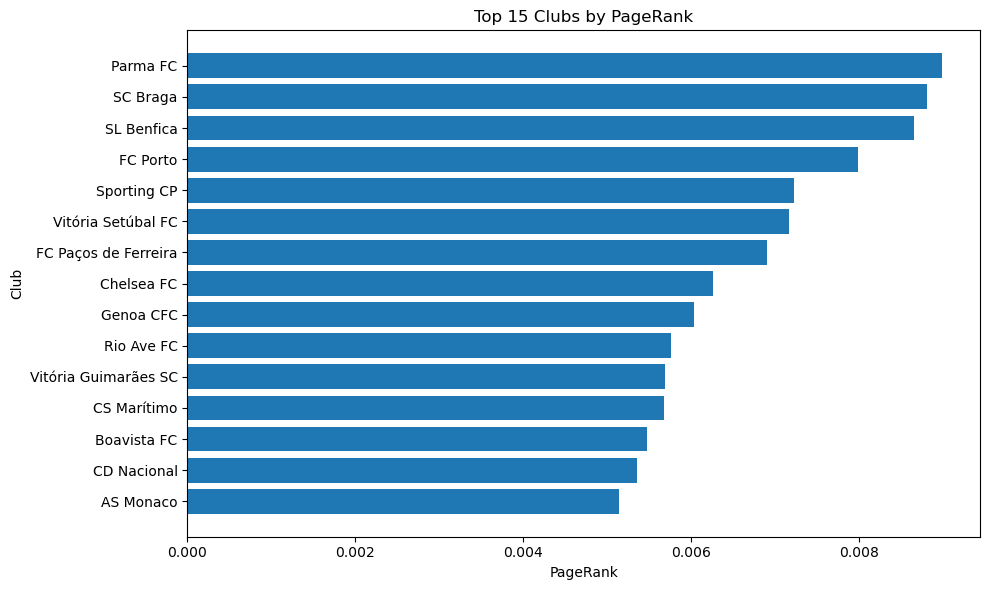

In [22]:
top_pagerank = club_nodes.sort_values("pagerank", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_pagerank["club"][::-1], top_pagerank["pagerank"][::-1])
plt.title("Top 15 Clubs by PageRank")
plt.xlabel("PageRank")
plt.ylabel("Club")
plt.tight_layout()
plt.show()

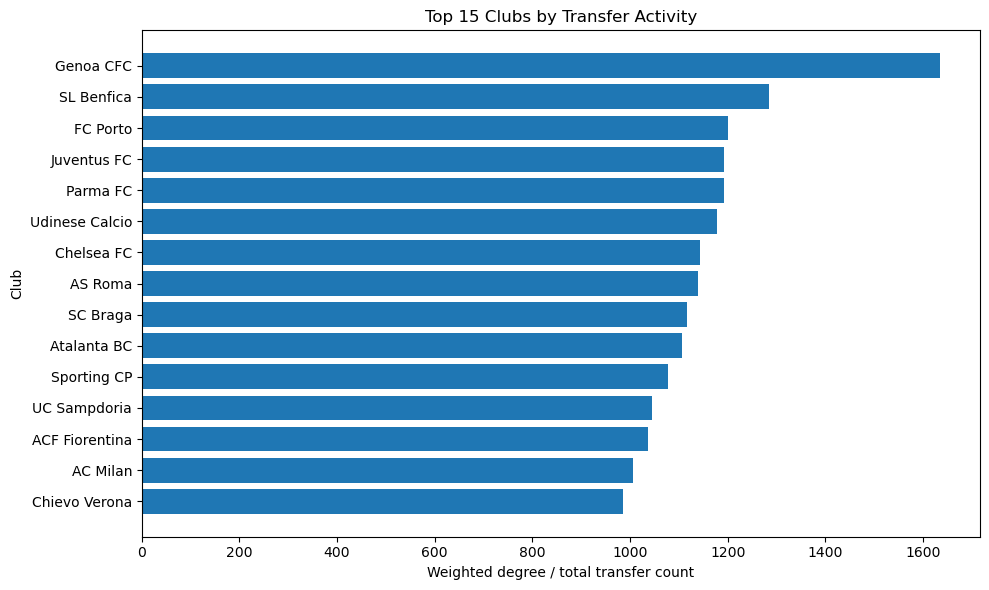

In [23]:
top_active = club_nodes.sort_values("weighted_degree", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_active["club"][::-1], top_active["weighted_degree"][::-1])
plt.title("Top 15 Clubs by Transfer Activity")
plt.xlabel("Weighted degree / total transfer count")
plt.ylabel("Club")
plt.tight_layout()
plt.show()

In [24]:
club_edges.to_csv(PROCESSED_DIR / "club_edges.csv", index=False)
club_nodes.to_csv(PROCESSED_DIR / "club_nodes.csv", index=False)

print("Saved club_edges.csv")
print("Saved club_nodes.csv")


Saved club_edges.csv
Saved club_nodes.csv


In [25]:
network_summary = pd.DataFrame({
    "metric": [
        "Number of clubs",
        "Number of directed edges",
        "Network density",
        "Total transfer records"
    ],
    "value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        nx.density(G),
        len(df)
    ]
})

network_summary

,metric,value
0,Number of clubs,3606.000000
1,Number of directed edges,31272.000000
2,Network density,0.002406
3,Total transfer records,66960.000000


In [26]:
network_summary.to_csv(PROCESSED_DIR / "network_summary.csv", index=False)
